In [1]:
import numpy as np
import pickle
import json
import os
from pathlib import Path
import torch


DATA_DIR = Path("/global/cfs/cdirs/m3246/gregork")
CKPT_DIR = Path("/global/cfs/cdirs/m3246/gregork/checkpoints")

# playlists = ["1A", "1B", "1E", "1M", "1P", "1D", "1L", "1G", "1O", "1C", "1F", "1A", "1N"]
playlists = ["1A"]

# To evaluate:
# - energy regression: CONT_max_blob_and_prong_log_1A_20260205_031125, CONT_max_blob_and_prong_log_PretrainedSmall_1A_20260205_031322
# - CC (current classification): cont_classification_current_type_1A_20260204_013605, CONT_classification_current_type_Pretrained_1A_20260203_202002
# - EC (event classification): cont_classification_event_type_1A_20260204_013827, CONT_classification_event_type_Pretrained_1A_20260203_201240


training_names = {
  "cc": {
    "1A": "cont_classification_current_type_1A_20260204_013605",
    "Pretrained_1A": "CONT_classification_current_type_Pretrained_1A_20260203_202002",
    "1A_TransformerSmall": "Train_CC_SmallModel_20260210_004255",
    "1A_Transformer": "Train_CC_20260210_003828"
  },
  "ec": {
    "1A": "cont_classification_event_type_1A_20260204_013827",
    "Pretrained_1A": "CONT_classification_event_type_Pretrained_1A_20260203_201240"
  },
  "er": {
    "1A": "CONT_max_blob_and_prong_log_1A_20260205_031125",
    "Pretrained_1A": "CONT_max_blob_and_prong_log_PretrainedSmall_1A_20260205_031322",
      "1A_TransformerSmall": "Train_Regression_SmallModel_20260210_003728",
      "1A_Transformer": "Train_Regression_20260210_003302"
  },
  "1pi_classification": {
    "1A_Transformer": "Train_CC1pi_20260210_190400",
  },
  "multi_pi_classification": {
    "1A_Transformer": "Train_MultiPi_20260213_122832",
  },
  "E_avail_regression": {
    "1A_Transformer": "Train_Regress_E_available2_20260214_232056"
  }
}



In [2]:
results = {}
configs = {}
for key in training_names.keys():
    results[key] = {}
    configs[key] = {}
    for model in training_names[key]:
        # File looks like this: CKPT_DIR/training_name/outputs_cont_classification_current_type_<PLAYLIST>_20260204_013605_minerva_<PLAYLIST>_0.npz
        results[key][model] = {}
        configs[key][model] = {}
        for playlist in playlists:
            path1 = CKPT_DIR / training_names[key][model] / "test_results" / f"outputs_{training_names[key][model]}_minerva_{playlist}_0.npz"
            path2 = CKPT_DIR / training_names[key][model] / "test_results" / f"outputs_best_model_minerva_{playlist}_0.npz"
            if path1.exists():
                results[key][model][playlist] = np.load(path1)
            elif path2.exists():
                results[key][model][playlist] = np.load(path2)
            else:
                raise ValueError(f"No results found for {training_names[key][model]} on playlist {playlist} - {path1} and {path2} do not exist")
            settings_path = CKPT_DIR / training_names[key][model] / "settings.json"
            if settings_path.exists():
                configs[key][model][playlist] = json.load(open(settings_path, "rb"))
            else:
                print(f"No settings found for {training_names[key][model]} on playlist {playlist}")
                configs[key][model][playlist] = {}


No settings found for Train_CC_SmallModel_20260210_004255 on playlist 1A
No settings found for Train_CC_20260210_003828 on playlist 1A
No settings found for Train_Regression_SmallModel_20260210_003728 on playlist 1A
No settings found for Train_Regression_20260210_003302 on playlist 1A
No settings found for Train_CC1pi_20260210_190400 on playlist 1A
No settings found for Train_MultiPi_20260213_122832 on playlist 1A
No settings found for Train_Regress_E_available2_20260214_232056 on playlist 1A


In [3]:
data_paths = {}
for key in training_names.keys():
    data_paths[key] = {}
    for model in training_names[key]:
        data_paths[key][model] = {}
        for playlist in playlists:
            data_paths[key][model][playlist] = {}
            #models[key][model][playlist]["settings"] = configs[key][model][playlist]
            model_path = CKPT_DIR / training_names[key][model] / "best_model.pt"
            if os.path.exists(model_path):
                data_paths[key][model][playlist] = torch.load(model_path, weights_only=False)["args"]["data_path"]
            else:
                print(f"No best model found for {training_names[key][model]} on playlist {playlist}")
                del data_paths[key][model][playlist]

No best model found for cont_classification_current_type_1A_20260204_013605 on playlist 1A
No best model found for CONT_classification_current_type_Pretrained_1A_20260203_202002 on playlist 1A
No best model found for cont_classification_event_type_1A_20260204_013827 on playlist 1A
No best model found for CONT_classification_event_type_Pretrained_1A_20260203_201240 on playlist 1A
No best model found for CONT_max_blob_and_prong_log_1A_20260205_031125 on playlist 1A
No best model found for CONT_max_blob_and_prong_log_PretrainedSmall_1A_20260205_031322 on playlist 1A


In [ ]:
Path(data_paths[key][model][playlist]) / playlist / "test" / "0.pb"

PosixPath('/global/cfs/cdirs/m3246/gregork/Minerva/20260213v2_split/1A/test/0.pb')

In [4]:
truth_labels = {}
for key in data_paths.keys():
    truth_labels[key] = {}
    for model in data_paths[key].keys():
        truth_labels[key][model] = {}
        for playlist in data_paths[key][model].keys():
            #try:
            truth_labels[key][model][playlist] = torch.load(open(Path(data_paths[key][model][playlist]) /  playlist /"test" / "0.pb", "rb"), weights_only=False)["truth_labels"]
            ##except:
            #    print(f"No test dataset found for {training_names[key][model]} on playlist {playlist}")
                #del test_datasets[key][model][playlist]

In [5]:
truth_labels["multi_pi_classification"]["1A_Transformer"]["1A"].shape

torch.Size([760041, 12])

In [6]:
t = results["er"]["1A"]["1A"]
y_pred = np.exp(t["prediction"]).flatten()
y_true = t["pid"].flatten()

In [7]:
np.mean(((np.log(y_true)-np.log(y_pred))**2))

np.float32(0.082144246)

### Energy regression

In [49]:
E_true_dict, E_pred_dict = {}, {}  # Eval. dataset -> model -> E_true, E_pred, E_pred_over_true mapping
E_pred_over_true_dict = {}

regression_task = "er"

for model in results[regression_task].keys():
    for eval_dataset in results[regression_task][model].keys():
        E_true = results[regression_task][model][eval_dataset]["pid"]
        E_pred = results[regression_task][model][eval_dataset]["prediction"].flatten()
        E_pred_over_true = E_pred / E_true
        if eval_dataset not in E_true_dict:
            E_true_dict[eval_dataset] = {}
            E_pred_dict[eval_dataset] = {}
            E_pred_over_true_dict[eval_dataset] = {}
        E_true_dict[eval_dataset][model] = E_true
        E_pred_dict[eval_dataset][model] = E_pred
        E_pred_over_true_dict[eval_dataset][model] = E_pred_over_true



In [50]:
results["E_avail_regression"]["1A_Transformer"]["1A"]["prediction"], results["E_avail_regression"]["1A_Transformer"]["1A"]["pid"]

(array([1.471 , 0.8843, 1.97  , ..., 1.433 , 2.314 , 3.545 ],
       shape=(760041,), dtype=float16),
 array([1.7485634, 1.0499398, 1.8975383, ..., 1.4250582, 2.2685027,
        3.6576178], shape=(760041,), dtype=float32))

In [51]:
results["er"]["1A_Transformer"]["1A"]["prediction"], results["er"]["1A_Transformer"]["1A"]["pid"]

(array([1.707, 1.168, 1.958, ..., 1.326, 2.398, 3.732],
       shape=(760041,), dtype=float16),
 array([1.8589281, 1.1512221, 1.8975387, ..., 1.44824  , 2.3002183,
        3.6729307], shape=(760041,), dtype=float32))

In [ ]:
from src.data.HEPTorchDataset import HEPTorchDataset
dataset_path = data_paths["er"]["1A_Transformer"]["1A"]
use_cond = False
use_pid = True
pid_idx = 0
use_add = False
num_add = 0



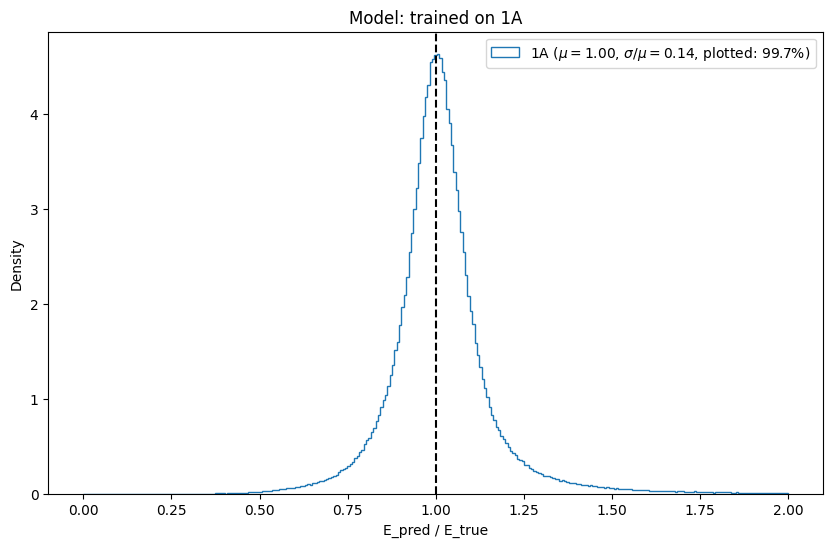

In [52]:
import matplotlib.pyplot as plt
bins = np.linspace(0, 2, 300)
fig, ax = plt.subplots(figsize=(10, 6))
model_name = "1A_Transformer"  # Select model "1A"
for eval_dataset in E_pred_over_true_dict.keys():
    if model_name in E_pred_over_true_dict[eval_dataset]:
        data = E_pred_over_true_dict[eval_dataset][model_name]
        # also compute and print RMS
        #print(f"{eval_dataset} (model {model_name}) RMS/median: {rms/mpv_data}")
        # fraction of events where e_reco / e_true is in [0, 2]
        mask = (data >= 0) & (data <= 2)
        frac_in_range = np.sum(mask) / len(data) * 100
        data = data[mask]
        mpv_data = np.median(data)
        rms = np.sqrt(np.mean((data - mpv_data)**2))
        ax.hist(data, bins=bins, density=True, histtype="step", label=eval_dataset + fr" ($\mu={mpv_data:.2f}$, $\sigma/\mu={rms/mpv_data:.2f}$, plotted: {frac_in_range:.1f}%)")
        # Also print the median and RMS/Median for each dataset on the plot
        #print(f"{eval_dataset} (model {model_name}) median: {mpv_data}")
        #print(f"{eval_dataset} (model {model_name}) RMS/median: {rms/mpv_data}")
#ax.set_yscale("log")
ax.axvline(1, color="black", linestyle="--")
ax.set_xlabel("E_pred / E_true")
ax.set_ylabel("Density")
ax.legend()
ax.set_title("Model: trained on 1A")
fig.show()



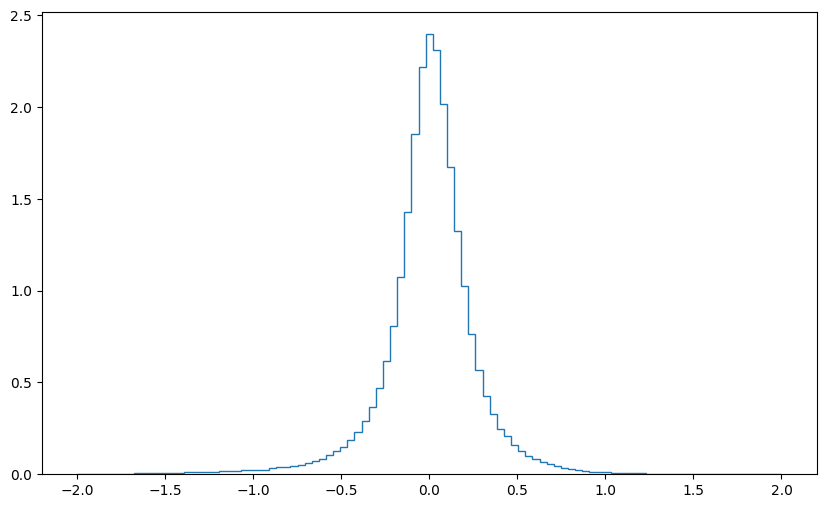

In [53]:
# plot abosolute E_pred-E_true
fig, ax = plt.subplots(figsize=(10, 6))
for eval_dataset in E_pred_over_true_dict.keys():
    if model_name in E_pred_dict[eval_dataset]:
        ax.hist((E_pred_dict[eval_dataset][model_name] - E_true_dict[eval_dataset][model_name]), bins=np.linspace(-2, 2, 100), density=True, histtype="step", label=eval_dataset)
fig.show()




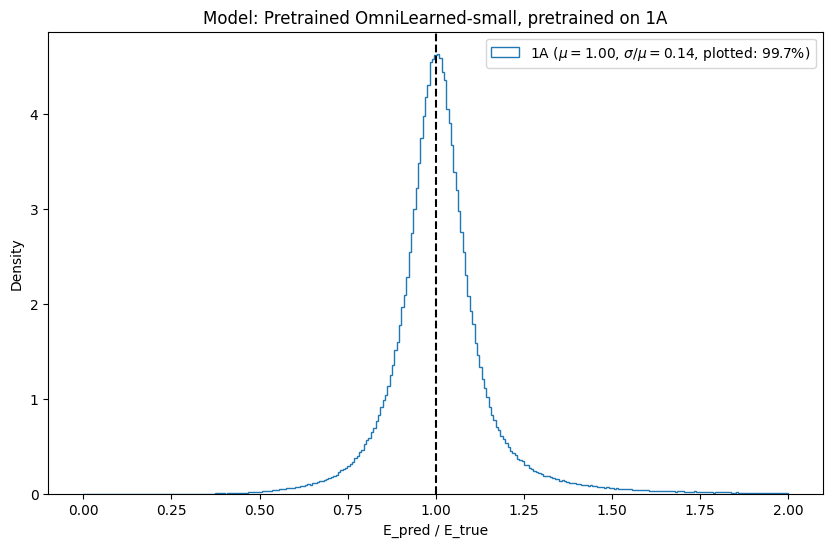

In [54]:
import matplotlib.pyplot as plt
bins = np.linspace(0, 2, 300)
fig, ax = plt.subplots(figsize=(10, 6))
model_name = "1A_Transformer"  # Select model "1A"
for eval_dataset in E_pred_over_true_dict.keys():
    if model_name in E_pred_over_true_dict[eval_dataset]:
        data = E_pred_over_true_dict[eval_dataset][model_name]
        # also compute and print RMS
        mask = (data >= 0) & (data <= 2)
        frac_in_range = np.sum(mask) / len(data) * 100
        data = data[mask]
        mpv_data = np.median(data)
        rms = np.sqrt(np.mean((data - mpv_data)**2))
        #print(f"{eval_dataset} (model {model_name}) RMS/median: {rms/mpv_data}")
        ax.hist(data, bins=bins, density=True, histtype="step", label=eval_dataset + fr" ($\mu={mpv_data:.2f}$, $\sigma/\mu={rms/mpv_data:.2f}$, plotted: {frac_in_range:.1f}%)")
        # Also print the median and RMS/Median for each dataset on the plot
        #print(f"{eval_dataset} (model {model_name}) median: {mpv_data}")
        #print(f"{eval_dataset} (model {model_name}) RMS/median: {rms/mpv_data}")
        
ax.axvline(1, color="black", linestyle="--")
ax.set_xlabel("E_pred / E_true")
ax.set_ylabel("Density")
ax.legend()
ax.set_title("Model: Pretrained OmniLearned-small, pretrained on 1A")
fig.show()





In [30]:


def get_Enu_fig(mc_E, reco_e_dict: dict):
    # reco_e_dict: key should be what's plotted. value should be same shape as mc_E, if it's not reconstructed, it should have value -1.
    # fig should have 2 x 2 subplots. left: counts; right: normalized histograms to unit area.
    # Top: E / 1000 histograms (GeV); Bottom: E_reco/E_mc
    import numpy as np
    import matplotlib.pyplot as plt
    # make the font of legend a bit smaller

    
    fig, ax = plt.subplots(2, 2, figsize=(12, 12))
    bins_E = np.linspace(0, 50, 300)
    bins_E_reco_over_true = np.linspace(0, 2, 100)
    ax[0, 0].hist(mc_E, bins=bins_E, histtype='step', color='black', label='MC E')
    ax[0, 1].hist(mc_E, bins=bins_E, histtype='step', color='black', label='MC E', density=True)
    
    # Store statistics for text boxes
    stats_text_10 = []  # for ax[1,0]
    stats_text_11 = []  # for ax[1,1]
    
    for method in reco_e_dict.keys():
        mask = reco_e_dict[method] > 0
        percentage_reconstructed = round(np.sum(mask) / len(mask) * 100, 1)
        ax[0, 0].hist(reco_e_dict[method], bins=bins_E, histtype='step', label=method + f" ({percentage_reconstructed}%)")
        ax[0, 1].hist(reco_e_dict[method], bins=bins_E, histtype='step', label=method + f" ({percentage_reconstructed}%)", density=True)
        E_reco_over_true = reco_e_dict[method][mask] / mc_E[mask]
        # MPV (Most Probable Value) - use the bin with max count
        counts, bin_edges = np.histogram(E_reco_over_true, bins=bins_E_reco_over_true)
        mpv_idx = np.argmax(counts)
        mpv = (bin_edges[mpv_idx] + bin_edges[mpv_idx + 1]) / 2
        # Calculate RMS from MPV
        # rms = np.sqrt(np.mean((E_reco_over_true - mpv)**2)) # compute rms from the values bounded by [0, 2]
        mask = (E_reco_over_true >= 0) & (E_reco_over_true <= 2)
        rms = np.sqrt(np.mean((E_reco_over_true[mask] - mpv)**2))
        ax[1, 0].hist(E_reco_over_true, bins=bins_E_reco_over_true, histtype='step', label=method + f" ({percentage_reconstructed}%)")
        ax[1, 1].hist(E_reco_over_true, bins=bins_E_reco_over_true, histtype='step', label=method + f" ({percentage_reconstructed}%)", density=True)
        # Add statistics to text lists
        stats_text_10.append(f"{method}: RMS={rms:.3f}, MPV={mpv:.3f}")
        stats_text_11.append(f"{method}: RMS={rms:.3f}, MPV={mpv:.3f}")
    fontsize_legend = 6.5
    ax[0, 0].legend(fontsize=fontsize_legend)
    ax[0, 0].set_xlabel("Energy [GeV]")
    ax[0, 0].set_ylabel("Counts")
    ax[0, 0].set_title("E nu Distribution")
    ax[0, 1].legend(fontsize=fontsize_legend)
    ax[0, 1].set_xlabel("Energy [GeV]")
    ax[0, 1].set_ylabel("Relative counts")
    ax[0, 1].set_title("E nu Distribution (normalized)")
    ax[1, 0].legend(fontsize=fontsize_legend)
    ax[1, 0].set_xlabel("E reco / E true")
    ax[1, 0].set_ylabel("Counts")
    ax[1, 0].set_title("E reco / E true Distribution")
    ax[1, 1].legend(fontsize=fontsize_legend)
    ax[1, 1].set_xlabel("E reco / E true")
    ax[1, 1].set_ylabel("Relative counts")
    ax[1, 1].set_title("E reco / E true Distribution (normalized)")
    
    # Add statistics text boxes to bottom plots
    stats_text_str_10 = '\n'.join(stats_text_10)
    stats_text_str_11 = '\n'.join(stats_text_11)
    
    ax[1, 0].text(0.98, 0.97, stats_text_str_10, transform=ax[1, 0].transAxes,
                  fontsize=8, verticalalignment='top', horizontalalignment='right',
                  bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax[1, 1].text(0.98, 0.97, stats_text_str_11, transform=ax[1, 1].transAxes,
                  fontsize=8, verticalalignment='top', horizontalalignment='right',
                  bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Put a grid on all
    ax[0, 0].grid(True)
    ax[0, 1].grid(True)
    ax[1, 0].grid(True)
    ax[1, 1].grid(True)

    # put legends on upper left for bottom plots to avoid overlap with stats
    ax[0, 0].legend(loc='lower right', fontsize=fontsize_legend)
    ax[0, 1].legend(loc='lower right', fontsize=fontsize_legend)
    ax[1, 0].legend(loc='upper left', fontsize=fontsize_legend)
    ax[1, 1].legend(loc='upper left', fontsize=fontsize_legend)
    fig.tight_layout()
    return fig


In [38]:
Enu_baselines = {} # Eval. dataset -> model -> Enu_baselines
mc_E = {}

model = "1A_Transformer"
for eval_dataset in configs[regression_task][model]:
    if eval_dataset not in Enu_baselines:
        Enu_baselines[eval_dataset] = {}
    settings = configs[regression_task][model][eval_dataset]
    if "path" not in settings:
        settings["path"] = data_paths[regression_task][model][eval_dataset]
    split_idx = os.path.join(settings["path"], "result.pkl")
    split_idx = pickle.load(open(split_idx, "rb"))
    current_baselines = os.path.join(settings["path"], "baselines", f"{eval_dataset}_enu_baselines.npz")
    current_baselines = np.load(current_baselines, mmap_mode="r")
    mc_E[eval_dataset] = current_baselines["E_true"][split_idx[eval_dataset]["test_idx"]] / 1000
    for key in current_baselines.keys():
        if key not in ["E_true", "E_muon"]:
            Enu_baselines[eval_dataset][key] = current_baselines[key][split_idx[eval_dataset]["test_idx"]] / 1000


In [40]:
models_to_plot = ["1A", "Pretrained_1A", "1A_TransformerSmall", "1A_Transformer"]
dataset_to_plot = "1A"

dict_model_E_reco = {key: E_pred_dict[dataset_to_plot][key] for key in models_to_plot}
dict_baselines_E_reco = Enu_baselines[dataset_to_plot]
get_Enu_fig(mc_E[dataset_to_plot], dict_model_E_reco).show()

KeyError: '1A'

In [ ]:
models_to_plot = ["1A_Transformer"]
dataset_to_plot = "1A"

dict_model_E_reco = {key: E_pred_dict[dataset_to_plot][key] for key in models_to_plot}
dict_baselines_E_reco = Enu_baselines[dataset_to_plot]
get_Enu_fig(mc_E[dataset_to_plot], dict_model_E_reco).show()

In [16]:
def get_baseline_and_models_E_filtered(E_true, baseline_E_reco, baseline_name, model_E_reco_dict):
    mask = baseline_E_reco >= 0
    baseline_E_reco = baseline_E_reco[mask]
    E_true = E_true[mask]
    output_dict = {}
    output_dict[baseline_name] = baseline_E_reco
    for model_name in model_E_reco_dict.keys():
        output_dict[model_name] = model_E_reco_dict[model_name][mask]
    return E_true, output_dict


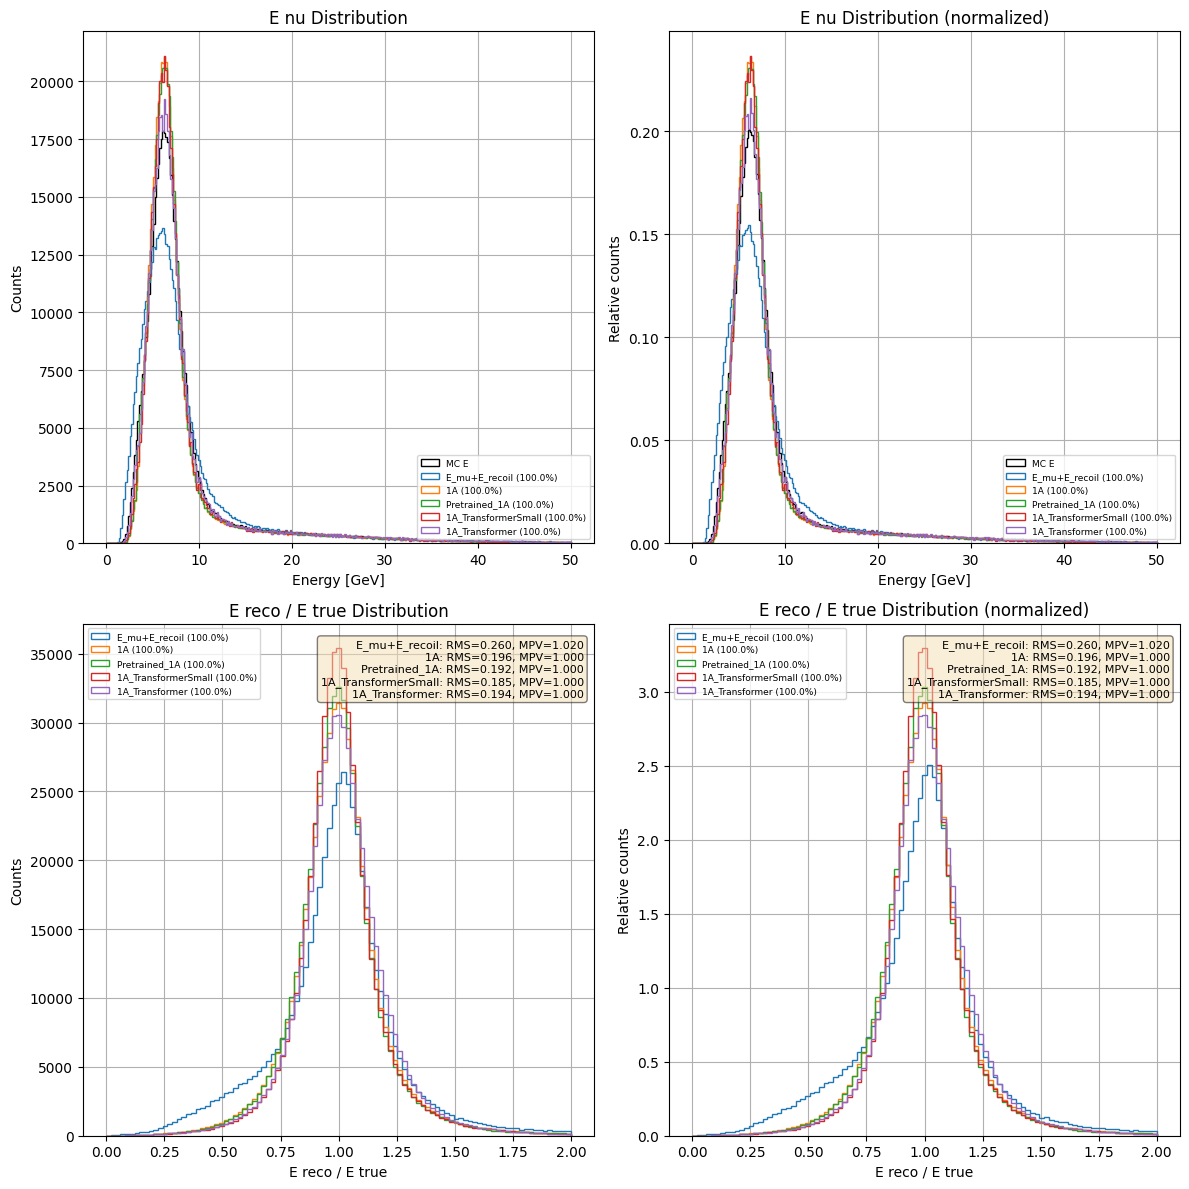

In [17]:
mc_E_filtered, methods_filtered = get_baseline_and_models_E_filtered(mc_E[dataset_to_plot], dict_baselines_E_reco["E_mu+E_recoil"], "E_mu+E_recoil", dict_model_E_reco)
get_Enu_fig(mc_E_filtered, methods_filtered).show()

### Classification tasks: binary (event current: CC or NC); multiclass (event type)

In [18]:
model_to_plot = "1A"
datasets = results["ec"][model_to_plot].keys()
labels_current_type = ["CC", "NC"]
labels_event_type = ["CCQE", "RES", "DIS", "Coherent", "2p2h"]
len(datasets)

1

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrix_on_ax(ax, y_true, y_pred, class_names):
    # Compute the confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    #ax.set_title("Confusion Matrix")
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)


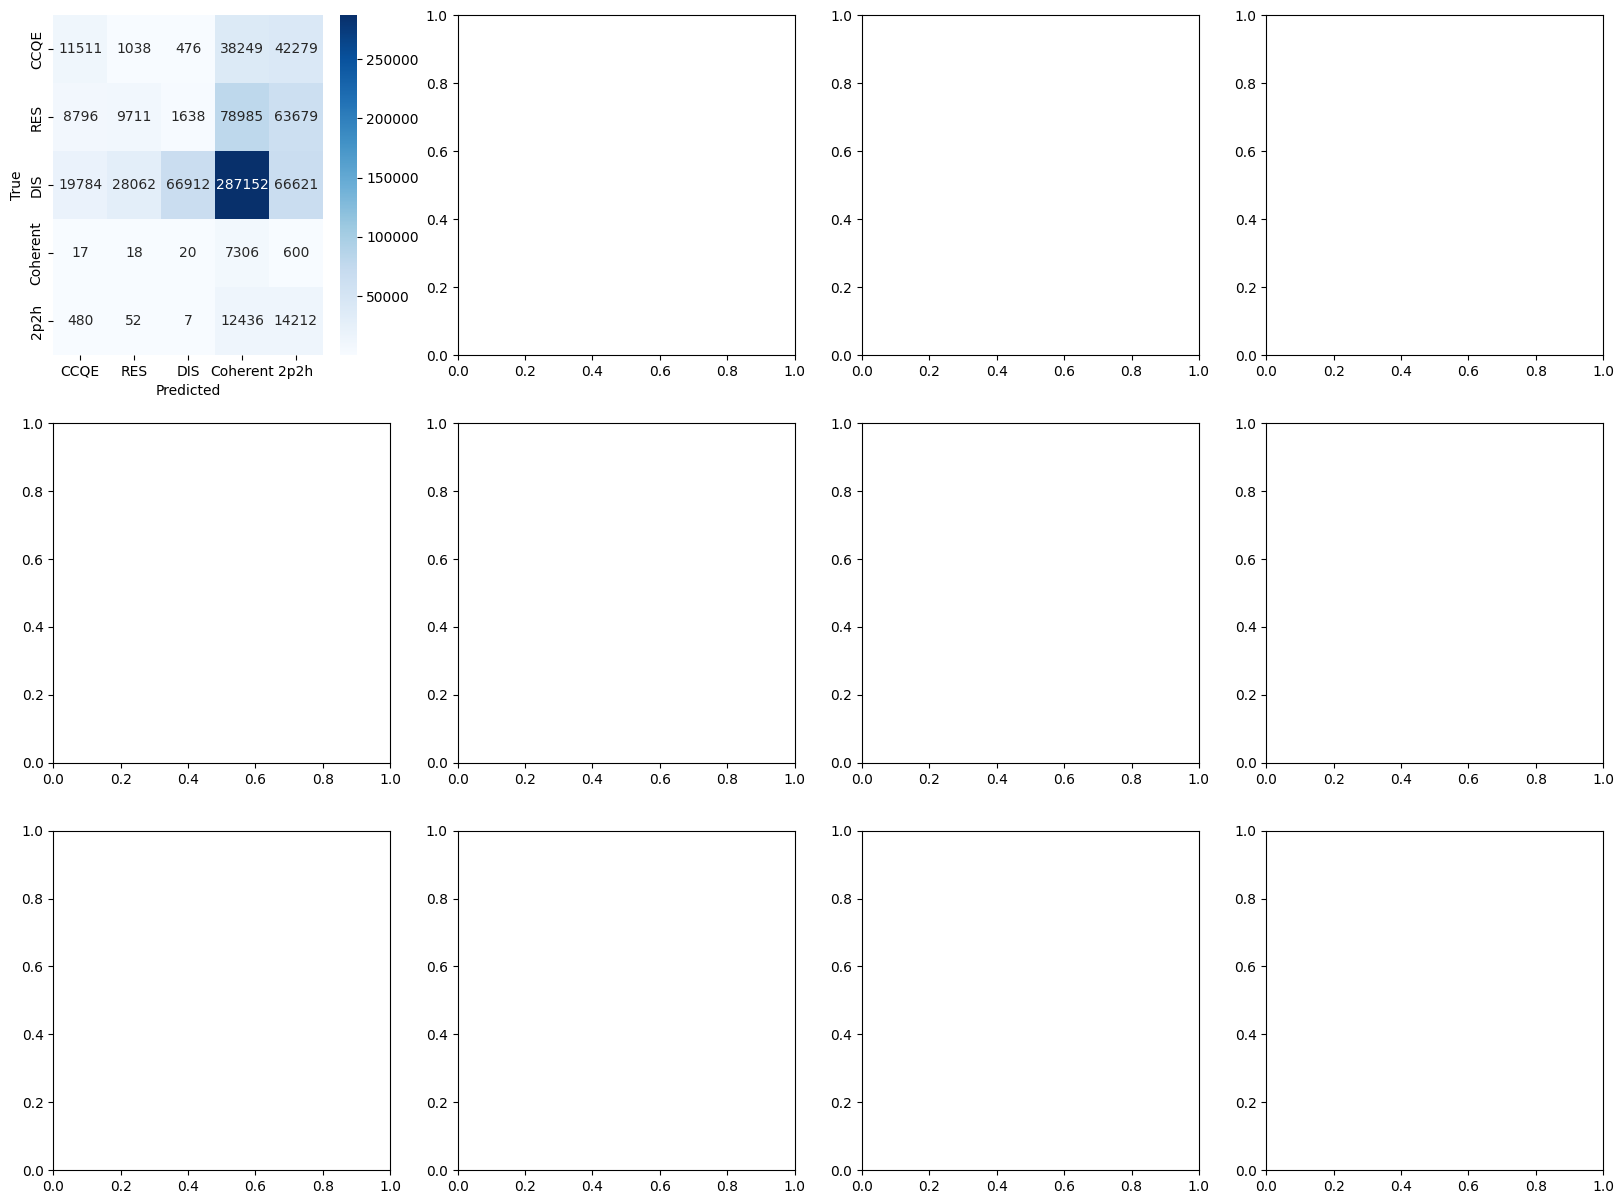

In [20]:
# 12 datasets: Make a 3x4 grid of confusion matrices
fig, ax = plt.subplots(3, 4, figsize=(20, 15))
for i, dataset in enumerate(datasets):
    plot_confusion_matrix_on_ax(ax[i // 4, i % 4], results["ec"][model_to_plot][dataset]["pid"], results["ec"][model_to_plot][dataset]["prediction"].argmax(axis=1), labels_event_type)
fig.show()


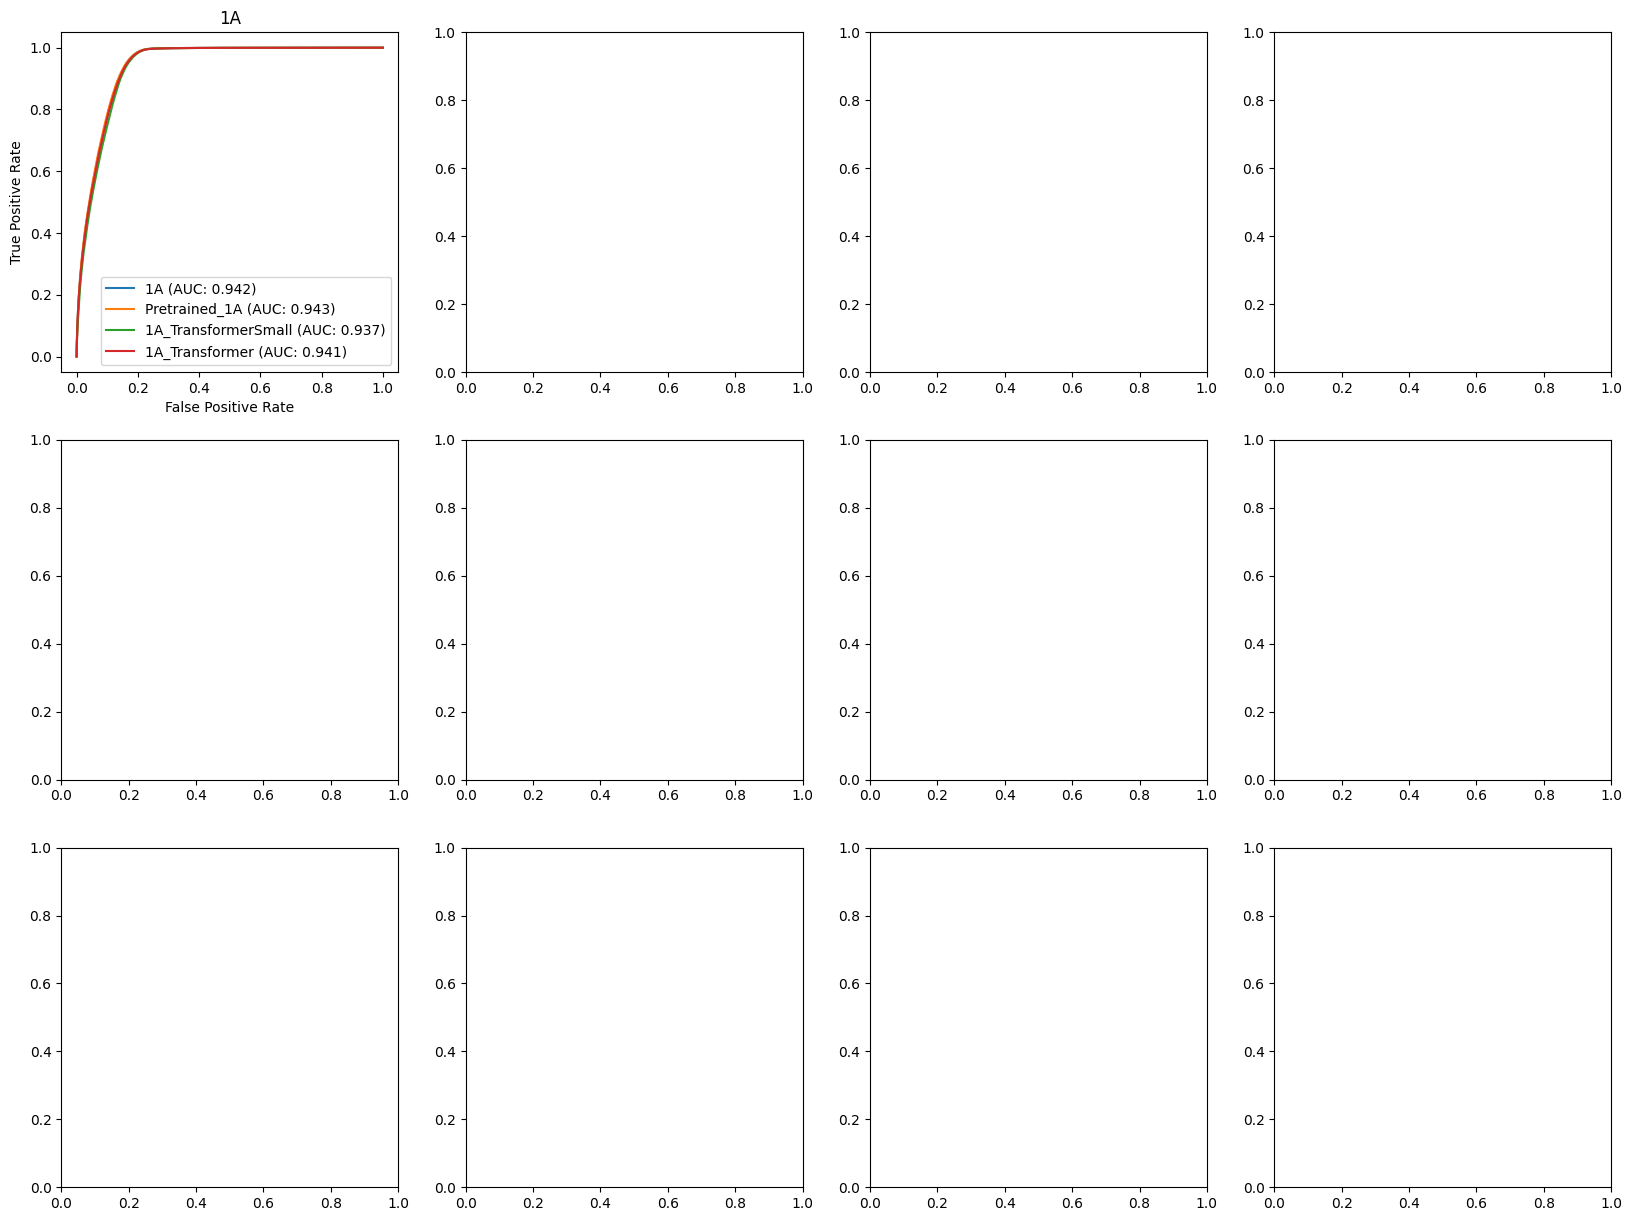

In [21]:
# now make a similar plot but of roc curves for binary classification (CC/NC)
from sklearn.metrics import roc_curve, auc

def plot_roc_curve_on_ax(ax, y_true, y_pred, class_names, label=None):
    fpr, tpr, thresholds = roc_curve(y_true, y_pred)
    auc_score = auc(fpr, tpr)
    if label:
        label = label + f" (AUC: {auc_score:.3f})"
    ax.plot(fpr, tpr, label=label)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    # also compute AUC and print it in a text box
    #ax.text(0.05, 0.95, f"AUC: {auc_score:.2f}", transform=ax.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='left')
    #ax.legend()

# 12 datasets: Make a 3x4 grid of ROC curves
fig, ax = plt.subplots(3, 4, figsize=(20, 15))
for model_to_plot in ["1A", "Pretrained_1A", "1A_TransformerSmall", "1A_Transformer"]:
    for i, dataset in enumerate(datasets):
        plot_roc_curve_on_ax(ax[i // 4, i % 4], results["cc"][model_to_plot][dataset]["pid"], results["cc"][model_to_plot][dataset]["prediction"][:, 1], labels_current_type, label=model_to_plot)
        # also plot the AUC metric on the top left of the plot
        # Turn on legend
        # NC is the positive class
        
for i, dataset in enumerate(datasets):
    ax[i // 4, i % 4].legend()
    ax[i // 4, i % 4].set_title(dataset)
    # Try doing log x and y scales
    #ax[i // 4, i % 4].set_xscale("log")
    #ax[i // 4, i % 4].set_yscale("log")
fig.show()


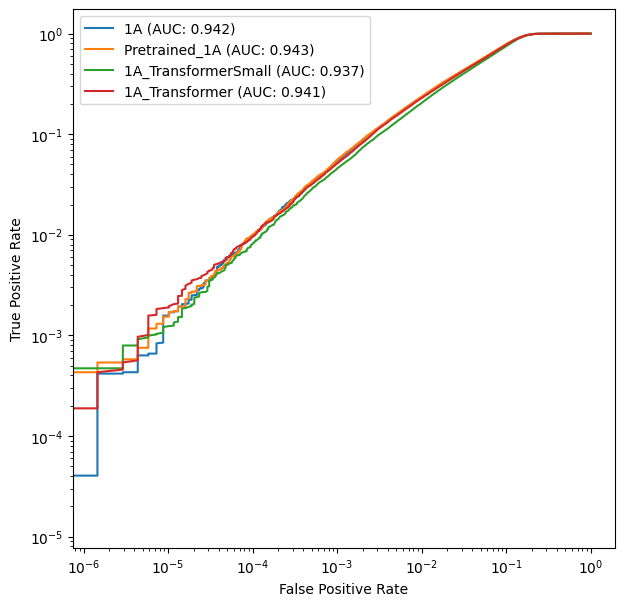

In [22]:
# just plot the 1A roc curve for different models
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
for model_to_plot in ["1A", "Pretrained_1A", "1A_TransformerSmall", "1A_Transformer"]:
    plot_roc_curve_on_ax(ax, results["cc"][model_to_plot]["1A"]["pid"], results["cc"][model_to_plot]["1A"]["prediction"][:, 1], labels_current_type, label=model_to_plot)
ax.legend()
ax.set_xscale("log")
ax.set_yscale("log")
fig.show()


In [23]:
# print the percentage of NC ground truth events in each dataset
for dataset in datasets:
    print(f"{dataset}: {np.sum(results['cc'][model_to_plot][dataset]['pid'] == 1) / len(results['cc'][model_to_plot][dataset]['pid'])}")


1A: 0.09783024863132384


In [24]:
y_true = results["1pi_classification"]["1A_Transformer"]["1A"]["pid"]
y_pred = results["1pi_classification"]["1A_Transformer"]["1A"]["prediction"].argmax(axis=1)

np.bincount(y_pred)
# Remove cases where y_true or y_pred is 1 (no CC1PiMinus events...)
mask = (y_true != 1) & (y_pred != 1)
y_true = y_true[mask]
y_pred = y_pred[mask]
# also rewrite y_true to be 0, 1 instead of 0, 2

np.bincount(y_pred)
y_true = y_true == 2
y_pred = results["1pi_classification"]["1A_Transformer"]["1A"]["prediction"][:, [0, 2]]

# There are only 1% positive labels in the dataset.

logits = results["1pi_classification"]["1A_Transformer"]["1A"]["prediction"][:, [0, 2]]
# do a softmax
probs = np.exp(logits) / np.sum(np.exp(logits), axis=1, keepdims=True)
probs = probs[:, 1]

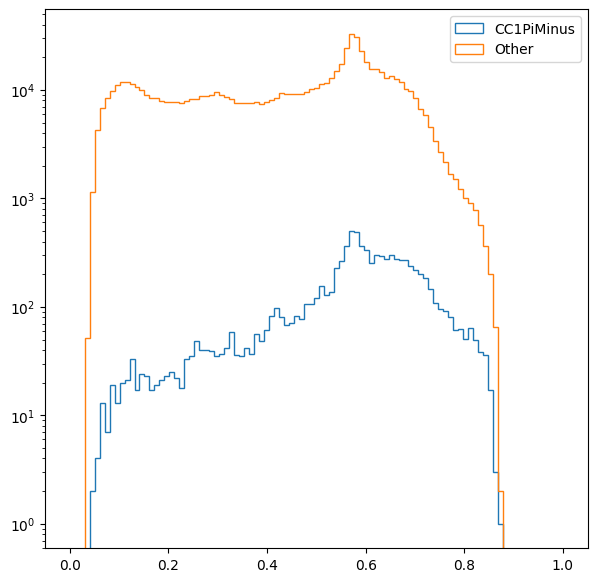

In [25]:
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
# make a  density hist of probs and y_true
ax.hist(probs[y_true], bins=np.linspace(0, 1, 100), density=False, label="CC1PiMinus", histtype="step")
ax.hist(probs[~y_true], bins=np.linspace(0, 1, 100), density=False, label="Other", histtype="step")
ax.legend()
ax.set_yscale("log")
fig.show()



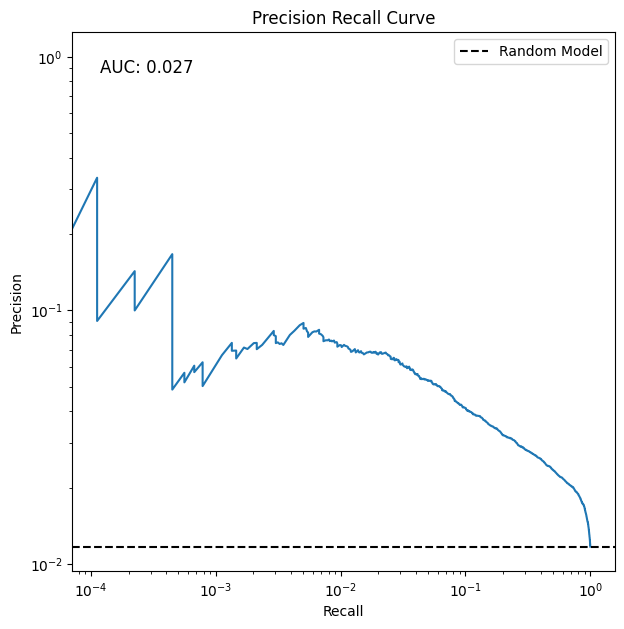

In [26]:
# precision recall curve
from sklearn.metrics import precision_recall_curve


precision, recall, thresholds = precision_recall_curve(y_true, probs)
precision_random, recall_random, _ = precision_recall_curve(y_true, np.random.permutation(probs))
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
ax.plot(recall, precision)
#ax.plot(recall_random, precision_random, color="black", linestyle="--", label="Random Model")
ax.axhline(y_true.mean(), color="black", linestyle="--", label="Random Model")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision Recall Curve")
ax.legend()
# compute area under the curve
auc_score = auc(recall, precision)
# plot curve for random model: horizontal line at y_true.mean
ax.text(0.05, 0.95, f"AUC: {auc_score:.3f}", transform=ax.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='left')
fig.show()


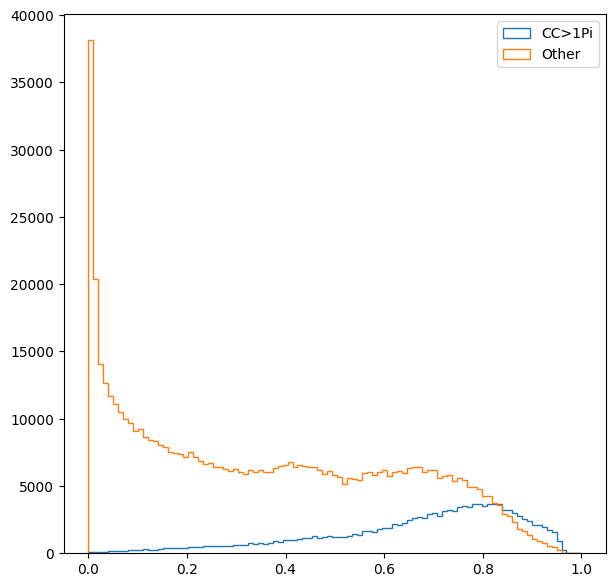

In [27]:
# There are only 1% positive labels in the dataset. Give me evaluation plots

logits = results["multi_pi_classification"]["1A_Transformer"]["1A"]["prediction"]
y_true = results["multi_pi_classification"]["1A_Transformer"]["1A"]["pid"]
probs = np.exp(logits) / np.sum(np.exp(logits), axis=1, keepdims=True)
probs = probs[:, 1]
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
ax.hist(probs[y_true==1], bins=np.linspace(0, 1, 100), density=False, label="CC>1Pi", histtype="step")
ax.hist(probs[y_true==0], bins=np.linspace(0, 1, 100), density=False, label="Other", histtype="step")
ax.legend()
#ax.set_yscale("log")

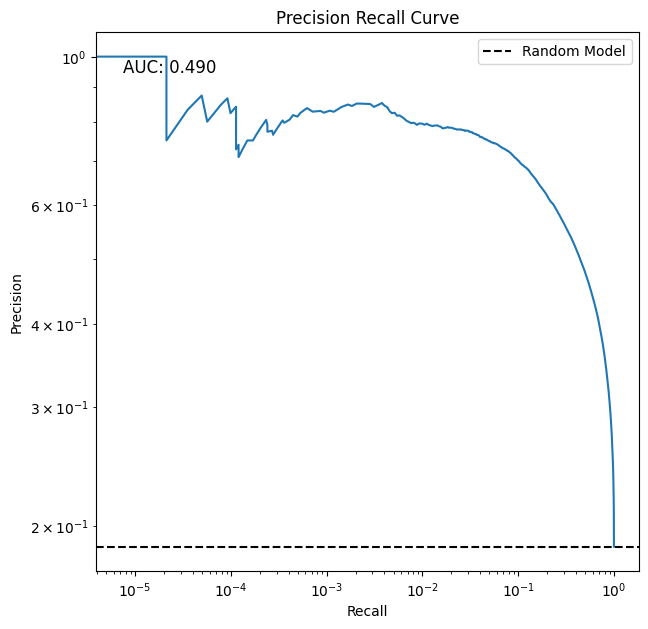

In [28]:
# make a precision recall curve
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_true, probs)
#precision_random, recall_random, _ = precision_recall_curve(y_true, np.random.permutation(probs))
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
ax.plot(recall, precision)
#ax.plot(recall_random, precision_random, color="black", linestyle="--", label="Random Model")
# hline
ax.axhline(y_true.mean(), color="black", linestyle="--", label="Random Model")
ax.legend()
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision Recall Curve")
# compute area under the curve
auc_score = auc(recall, precision)
ax.text(0.05, 0.95, f"AUC: {auc_score:.3f}", transform=ax.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='left')
fig.show()

In [29]:
test_dataset = "1A"
path = Path(settings["path"]) / "test" / f"{test_dataset}.pkl"


In [30]:
pion_four_vector_MC = truth_labels["1pi_classification"]["1A_Transformer"]["1A"][:, -4:]
pion_E_MC = pion_four_vector_MC[:, 0] / 1000.0

In [31]:
# Make an efficiency plot vs GT pion energy

y_true = results["1pi_classification"]["1A_Transformer"]["1A"]["pid"]
y_pred = results["1pi_classification"]["1A_Transformer"]["1A"]["prediction"].argmax(axis=1)

np.bincount(y_pred)
# Remove cases where y_true or y_pred is 1 (no CC1PiMinus events...)
mask = (y_true != 1) & (y_pred != 1)
y_true = y_true[mask]
y_pred = y_pred[mask]

# Also, rewrite y_true to be 0, 1 instead of 0, 2
np.bincount(y_pred)
y_true = y_true == 2
y_pred =  results["1pi_classification"]["1A_Transformer"]["1A"]["prediction"][:, [0, 2]]

# There are only 1% positive labels in the dataset.
logits = results["1pi_classification"]["1A_Transformer"]["1A"]["prediction"][:, [0, 2]]
# Do a softmax
probs = np.exp(logits) / np.sum(np.exp(logits), axis=1, keepdims=True)
probs = probs[:, 1]


In [32]:
pion_E_MC_bins = np.array([0, 0.5, 0.75, 1.0, 2.0])
bin_middles = (pion_E_MC_bins[:-1] + pion_E_MC_bins[1:]) / 2
thresholds = np.linspace(0.5, 0.9, 10)
efficiency = {} # Threshold -> efficiency
purity = {} # Simply threshold -> Purity of the selected events (there is no pion mass involved)
for threshold in thresholds:
    efficiency[threshold] = []
    # Purity is percentage of selected events that have GT label 1
    mask = probs > threshold
    if mask.sum().item() > 0:
        purity[threshold] = y_true[mask].sum().item() / mask.sum().item()
    else:
        purity[threshold] = 0
    for i in range(len(pion_E_MC_bins) - 1):
        mask = (pion_E_MC > pion_E_MC_bins[i]) & (pion_E_MC <= pion_E_MC_bins[i+1])
        N_GT_pions = mask.sum().item()
        #print("N pions in bin", i, mask.sum().item())
        mask = mask & (probs > threshold)
        mask_sum = mask.sum().item()    
        if N_GT_pions > 0:
            efficiency[threshold].append(mask_sum / N_GT_pions)
        else:
            efficiency[threshold].append(0)


/tmp/ipykernel_599994/3569644144.py:18: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  mask = mask & (probs > threshold)


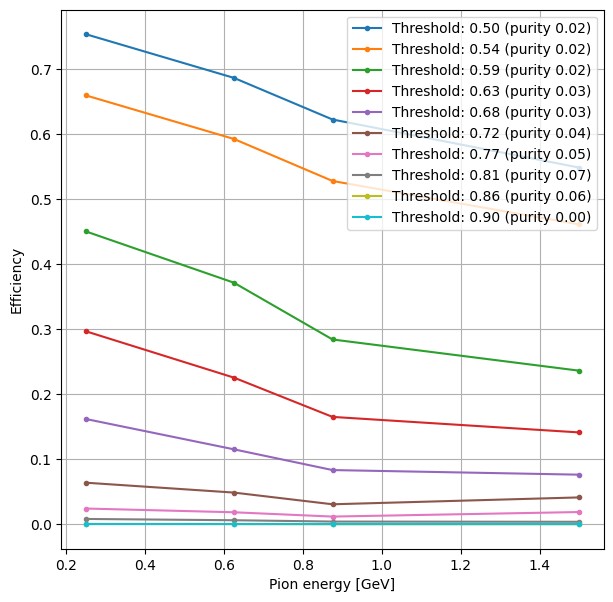

In [33]:
# Now, make a plot of pion energy (middle of bin) vs efficiency for each threshold
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
for threshold in thresholds:
    ax.plot(bin_middles, efficiency[threshold], ".-", label=f"Threshold: {threshold:.2f} (purity {purity[threshold]:.2f})")
ax.legend()
ax.set_xlabel("Pion energy [GeV]")
ax.set_ylabel("Efficiency")
ax.grid()

array([0.4995, 0.4277, 0.509 , ..., 0.3909, 0.255 , 0.3   ],
      shape=(760041,), dtype=float16)